In [1]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import xarray as xr
import matplotlib.colors as colors
import metpy
import cmaps
import matplotlib
from scipy.signal import detrend

In [2]:
# Compare SE, FV3, and MPAS
# All using 1 minute output
# 1 degree horizontal resolution

# Save the figures?
save_the_fig = True

case = 'p_pert'
#case = 'acid'

if case == 'p_pert':
    # Compare the 50km model top runs
    se_case = 'CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb'
    se_run_base = '/glade/derecho/scratch/nforcone/'
    se_nc_file = se_case + '.cam.h0i.0001-01-01-00000.nc'
    
    fv3_case = 'cam_6_4_095_lamb_fv3_C96_ztop_50km_dt_1min'
    fv3_run_base = "/glade/derecho/scratch/timand/"
    fv3_nc_file = fv3_case + '.cam.h0i.0001-01-01-00000_p_pert.regrid.1x1.nc'

    mpas_case = 'cam_6_4_161.MPAS120.L100.top_50km.fadiab.pressure_perturb'
    mpas_run_base = '/glade/derecho/scratch/cjablono/'    
    mpas_nc_file = mpas_case + '.cam.h0i.0001-01-01-00000.1min.regrid.1x1.18h.epssm_0.1.cpair_default.50hPa.nc'
elif case == 'acid':
    se_case = 'CAM_6_4_089_ne30_ne30_mg16_L58_dz500m_acid_1min'
    se_run_base = '/glade/derecho/scratch/nforcone/'
    se_nc_file = 'CAM_6_4_089_ne30_ne30_mg16_L58_dz500m_acid_1min.cam.h0i.0001-01-01-00000.nc'
    
    fv3_case = 'cam_6_4_095_paper_nine_fv3_C96_small_dt'
    fv3_run_base = "/glade/derecho/scratch/timand/"
    fv3_nc_file = fv3_case + '.cam.h0i.0001-01-01-00000_acid_L58.regrid.1x1.nc'

    mpas_case = 'cam_6_4_161.MPAS120.L100.top_50km.fadiab.pressure_perturb'
    mpas_run_base = '/glade/derecho/scratch/cjablono/'    
    mpas_nc_file = mpas_case + '.cam.h0i.0001-01-01-00000.1min.regrid.1x1.18h.nc'
    

#run_base = "/glade/derecho/scratch/timand/"
se_run_path = se_run_base + se_case + '/run/' + se_nc_file
fv3_run_path = fv3_run_base + fv3_case + '/run/' + fv3_nc_file
mpas_run_path = mpas_run_base + mpas_case + '/run/' + mpas_nc_file

nc_se = Dataset(se_run_path, 'r')
nc_fv3 = Dataset(fv3_run_path, 'r')
nc_mpas = Dataset(mpas_run_path, 'r')


In [3]:
time = nc_fv3['time'][:]
lat_deg = nc_fv3['lat'][:] 
lon_deg = nc_fv3['lon'][:] 

lat = lat_deg*np.pi/180
lon = lon_deg*np.pi/180

LON, LAT = np.meshgrid(lon_deg, lat_deg)

print(np.min(lon))
print(np.max(lon))
print(np.min(lat))
print(np.max(lat))

0.0
6.265732014659642
-1.5707963267948966
1.5707963267948966


In [4]:
# Choose the field to look at
p0 = 1e5
if case=='p_pert':
    field_name = 'PS'
elif case == 'acid':
    field_name = 'OMEGA850'

field_se = nc_se[field_name][:]
field_fv3 = nc_fv3[field_name][:]
field_mpas = nc_mpas[field_name][:]

print(np.shape(field_se))
print(np.shape(field_fv3))
print(np.shape(field_mpas))

(1081, 181, 360)
(1081, 181, 360)
(1081, 181, 360)


In [5]:
# Take fft in space and time.
# Do for a zonal slice in each model

# Lat index of equator
eq_idx = np.argmin(np.abs(lat_deg))

se_zonal = field_se[:, eq_idx, :]
fv3_zonal = field_fv3[:, eq_idx, :]
mpas_zonal = field_mpas[:, eq_idx, :]

k_no = 360
omega_no = len(field_se[:,0,0])
print(omega_no)

print(np.shape(se_zonal))

1081
(1081, 360)


In [6]:
# Temporal detrending, as the time axis is not periodic
se_zonal = detrend(se_zonal, axis=0, type="linear")
se_window = np.hanning(se_zonal.shape[0])[:, None]
se_zonal = se_zonal * se_window

fv3_zonal = detrend(fv3_zonal, axis=0, type="linear")
fv3_window = np.hanning(fv3_zonal.shape[0])[:, None]
fv3_zonal = fv3_zonal * fv3_window

mpas_zonal = detrend(mpas_zonal, axis=0, type="linear")
mpas_window = np.hanning(mpas_zonal.shape[0])[:, None]
mpas_zonal = mpas_zonal * mpas_window

In [7]:
# Use rfft in space and fft in time:
se_zonal_fft = np.fft.rfft2(se_zonal)
fv3_zonal_fft = np.fft.rfft2(fv3_zonal)
mpas_zonal_fft = np.fft.rfft2(mpas_zonal)

print(np.shape(se_zonal_fft))

(1081, 181)


In [8]:
se_pow_raw = np.abs(se_zonal_fft)**2
fv3_pow_raw = np.abs(fv3_zonal_fft)**2
mpas_pow_raw = np.abs(mpas_zonal_fft)**2

In [9]:
# Create wavenumber, omega axes
dt = 60  # output timestep (seconds)
R = 6371220
dx = 2 * np.pi * R / 360  # horizontal grid spacing at the equator in meters
print(dx)

omega = 2*np.pi*np.fft.fftfreq(omega_no, d=dt)
k = 2*np.pi*np.fft.rfftfreq(k_no, d=dx)

# Just look at positive region and up to a maximum frequency
omega_max = 10
omega_inds = (omega >= 0.0) & (omega < 0.006)
omega_crop = omega[omega_inds]

k_km = k*1000

# If want to crop the wavenumbers, too.
lambda_min = 4 * dx  # Assume effective resolution of 6dx
k_eff = 2 * np.pi / lambda_min
#k_inds = k < k_eff
k_inds = k <= 0.000016

k_km_crop = k_km[k_inds]

K, OMEGA = np.meshgrid(k_km_crop, omega_crop)

se_pow = se_pow_raw[omega_inds, :]
fv3_pow = fv3_pow_raw[omega_inds, :]
mpas_pow = mpas_pow_raw[omega_inds, :]

se_pow = se_pow[:, k_inds]
fv3_pow = fv3_pow[:, k_inds]
mpas_pow = mpas_pow[:, k_inds]

d_omega = omega[1] - omega[0]
d_k = k[1] - k[0]

print(d_omega)
print(d_k)

111198.76636891312
9.687303896360757e-05
1.569558106610665e-07


In [10]:
# Theoretical curves
# For T0 = 275 K
# 50 km model top
T0 = 275.0


gamma = 1.4
Rd = 287.0
T0 = 275.0
g= 9.81
cp=1004

cs = np.sqrt(gamma * Rd * T0)

H = Rd*T0/g

N = np.sqrt(g**2/(cp*T0))

ztop = 5e4  # m
m0 = 0.0
m1 = np.pi / ztop
m2 = 2*np.pi / ztop

lamb_omega = cs*k
grav_m0_omega = N*k/np.sqrt(k**2 + m0**2 + 1/(4*H**2))
grav_m1_omega = N*k/np.sqrt(k**2 + m1**2 + 1/(4*H**2))
grav_m2_omega = N*k/np.sqrt(k**2 + m2**2 + 1/(4*H**2))

0.00941734863966399


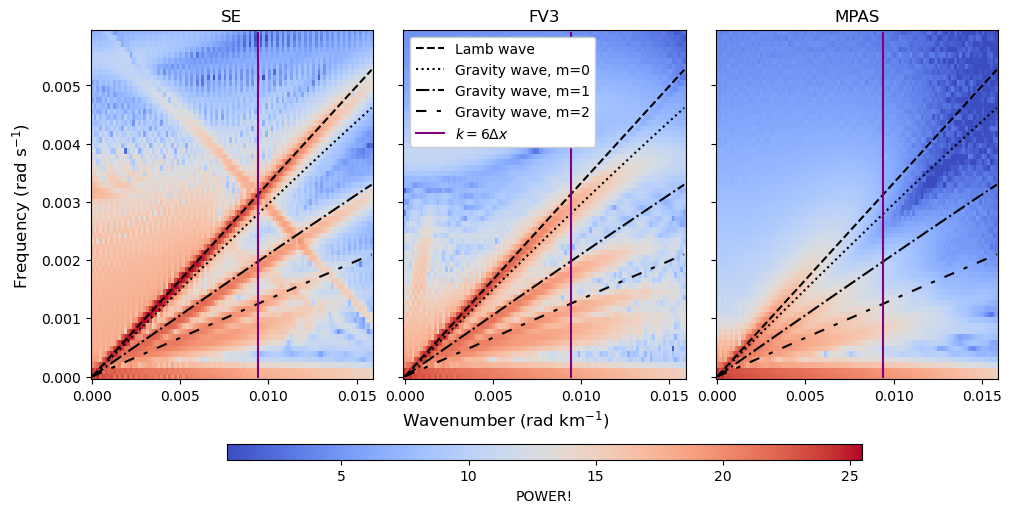

In [30]:
# Set a shared scale for all maps.
# Base of SE
vmin = np.min(np.log(se_pow))
vmax = np.max(np.log(se_pow))


# Plot the wavenumber-frequency diagram
fig, axes = plt.subplots(1,3, figsize=(10,5), constrained_layout=True, sharey=True)
ax1, ax2, ax3 = axes
plot1 = ax1.pcolormesh(K, OMEGA, np.log(se_pow), shading="nearest", cmap='coolwarm', vmin=vmin, vmax=vmax)
plot2 = ax2.pcolormesh(K, OMEGA, np.log(fv3_pow), shading="nearest", cmap='coolwarm', vmin=vmin, vmax=vmax)
plot3 = ax3.pcolormesh(K, OMEGA, np.log(mpas_pow), shading="nearest", cmap='coolwarm', vmin=vmin, vmax=vmax)

ax1.set_title('SE')
ax2.set_title('FV3')
ax3.set_title('MPAS')

for ax in axes:
    ax.set_xticks([0,0.005, 0.01, 0.015])

k_km_6dx = 1000* 2*np.pi / (6*dx)
print(k_km_6dx)

# Add lines for expected
ax1.plot(k_km_crop, lamb_omega[k_inds], label='Lamb wave', c='k', linestyle='--')
ax1.plot(k_km_crop, grav_m0_omega[k_inds], label='Gravity wave, m=0', c='k', linestyle=':')
ax1.plot(k_km_crop, grav_m1_omega[k_inds], label='Gravity wave, m=1',c='k', linestyle='-.')
ax1.plot(k_km_crop, grav_m2_omega[k_inds], label='Gravity wave, m=2',c='k', linestyle=(0, (5, 5, 2, 5)))
ax1.plot(np.ones_like(omega_crop)*k_km_6dx, omega_crop, c='purple')
ax2.plot(k_km_crop, lamb_omega[k_inds], label='Lamb wave', c='k',linestyle='--')
ax2.plot(k_km_crop, grav_m0_omega[k_inds], label='Gravity wave, m=0',c='k', linestyle=':')
ax2.plot(k_km_crop, grav_m1_omega[k_inds], label='Gravity wave, m=1',c='k', linestyle='-.')
ax2.plot(k_km_crop, grav_m2_omega[k_inds], label='Gravity wave, m=2',c='k', linestyle=(0, (5, 5, 2, 5)))
ax2.plot(np.ones_like(omega_crop)*k_km_6dx, omega_crop, c='purple', label=r'$k=6\Delta x$')
ax3.plot(k_km_crop, lamb_omega[k_inds], label='Lamb wave', c='k',linestyle='--')
ax3.plot(k_km_crop, grav_m0_omega[k_inds], label='Gravity wave, m=0',c='k', linestyle=':')
ax3.plot(k_km_crop, grav_m1_omega[k_inds], label='Gravity wave, m=1',c='k', linestyle='-.')
ax3.plot(k_km_crop, grav_m2_omega[k_inds], label='Gravity wave, m=2',c='k', linestyle=(0, (5, 5, 2, 5)))
ax3.plot(np.ones_like(omega_crop)*k_km_6dx, omega_crop, c='purple')
ax2.legend(framealpha=1)

cb = plt.colorbar(plot3, ax=axes, shrink=0.7, pad=0.1, aspect=40, location='bottom')
cb.set_label(label=r"POWER!")

fig.supxlabel(r'Wavenumber (rad km$^{-1}$)', y=0.15)
fig.supylabel('Frequency (rad s$^{-1}$)', y=0.6)

if save_the_fig:
    if case == 'p_pert':
        plt.savefig(f'figures/p_pert_k_omega', bbox_inches='tight')
    elif case == 'acid':
        plt.savefig(f'figures/acid_k_omega', bbox_inches='tight')